In [1]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score,accuracy_score,confusion_matrix,precision_score,f1_score,roc_curve,auc,multilabel_confusion_matrix
import pandas as pd
import optuna
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train=pd.read_csv(r"D:\ML Project\Data Splits\X_train.csv")
X_val=pd.read_csv(r"D:\ML Project\Data Splits\X_val.csv")
X_test=pd.read_csv(r"D:\ML Project\Data Splits\X_test.csv")

Y_train=pd.read_csv(r"D:\ML Project\Data Splits\Y_train.csv")['class']
Y_val=pd.read_csv(r"D:\ML Project\Data Splits\Y_val.csv")['class']
Y_test=pd.read_csv(r"D:\ML Project\Data Splits\Y_test.csv")['class']

In [3]:
# n_estimators = list(range(50, 350, 50))
# learning_rate = [round(x, 2) for x in np.arange(0.01, 0.31, 0.01)]
# max_depth = list(range(3, 11))
# subsample = [round(x, 1) for x in np.arange(0.1, 1.1, 0.1)]
# colsample_bytree = [round(x, 1) for x in np.arange(0.1, 1.1, 0.1)]
# gamma = [round(x, 1) for x in np.arange(0, 5.1, 0.1)]
# reg_alpha = [round(x, 1) for x in np.arange(0.1, 1.1, 0.1)]
# reg_lambda = list(range(1, 11))


In [4]:
def objective(trial):
    n_estimators=trial.suggest_int('n_estimators',50,300)
    learning_rate=trial.suggest_float('learning_rate',0.1,0.5)
    max_depth=trial.suggest_int('max_depth',3,10)
    subsample=trial.suggest_float('subsample',0.1,1)
    colsample_bytree=trial.suggest_float('colsample_bytree',0.1,1)
    gamma=trial.suggest_float('gamma',0,5)
    reg_alpha=trial.suggest_float('reg_alpha',0.1,1)
    reg_lambda=trial.suggest_float('reg_lambda',1,11)


    model=XGBClassifier(n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,subsample=subsample,colsample_bytree=colsample_bytree,gamma=gamma,reg_alpha=reg_alpha,reg_lambda=reg_lambda,random_state=50)
    model.fit(X_train,Y_train)
    Y_val_pred=model.predict(X_val)
    accuracy_val=accuracy_score(Y_val,Y_val_pred)

    return accuracy_val


study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)

# direction='maximize' since we are working on acuracy which needs to be maximized

[I 2026-05-25 12:42:03,326] A new study created in memory with name: no-name-9d7c2d5f-6fc2-46bf-af00-acb1863c2424
[I 2026-05-25 12:42:06,604] Trial 0 finished with value: 0.991 and parameters: {'n_estimators': 54, 'learning_rate': 0.4761533139972428, 'max_depth': 5, 'subsample': 0.3058588358555784, 'colsample_bytree': 0.43814978285856665, 'gamma': 0.6776325836494301, 'reg_alpha': 0.31512774328723414, 'reg_lambda': 6.829340746227379}. Best is trial 0 with value: 0.991.
[I 2026-05-25 12:42:12,647] Trial 1 finished with value: 0.9912 and parameters: {'n_estimators': 134, 'learning_rate': 0.2723538872976839, 'max_depth': 10, 'subsample': 0.5712027647870476, 'colsample_bytree': 0.7463939514775818, 'gamma': 1.681888017631733, 'reg_alpha': 0.8646630253638677, 'reg_lambda': 2.4962842539434327}. Best is trial 1 with value: 0.9912.
[I 2026-05-25 12:42:19,877] Trial 2 finished with value: 0.9919 and parameters: {'n_estimators': 217, 'learning_rate': 0.2905231131752584, 'max_depth': 10, 'subsample

In [5]:
optuna_XGB = study.trials_dataframe()
optuna_XGB.to_csv(r"D:\ML Project\Model_Tuned_Parameter_data\Optuna_XGB.csv", index=False)

In [6]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\XGB.json", "w") as f:
    input=study.best_trial.params
    input['Accuracy']=study.best_trial.value
    json.dump(input, f)

In [7]:
print(f'Validation best accuracy: {study.best_trial.value}')
print(f'Validation best parameters: {study.best_trial.params}')

Validation best accuracy: 0.9923
Validation best parameters: {'n_estimators': 230, 'learning_rate': 0.1891680078408332, 'max_depth': 9, 'subsample': 0.7053035760373845, 'colsample_bytree': 0.38117175410012644, 'gamma': 0.7343668706341724, 'reg_alpha': 0.39693942619866696, 'reg_lambda': 10.176033723488487}


In [8]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\XGB.json", "r") as f:
    loaded_dict = json.load(f)

params = dict(list(loaded_dict.items())[:-1])
validation_accuracy=loaded_dict['Accuracy']

In [9]:
model_best=XGBClassifier(**params,random_state=50)  # *8 unpacks the dictionary and allows us to pass the dictionary keys as keywords (parameter keywords) in the function

# Dictionary Unpacking in Function CallsThe ** operator allows you to take key-value pairs from a dictionary and pass them as named keyword arguments to a function. Experts on Stack Overflow explain that this enables dynamic argument handling.pythondef greet(name, age):
#     print(f"Hello {name}, you are {age} years old.")

# data = {"name": "Alice", "age": 25}
# greet(**data)  # Equivalent to greet(name="Alice", age=25)
# Use code with caution.3. Collecting Arguments (**kwargs)In a function definition, ** collects any number of keyword arguments into a single dictionary, typically named kwargs. A guide on Medium highlights how this provides a shortcut for accepting flexible inputs.pythondef show_info(**kwargs):
#     for key, value in kwargs.items():
#         print(f"{key}: {value}")

# show_info(city="New York", job="Developer") 
# # kwargs becomes {'city': 'New York', 'job': 'Developer'}
# Use code with caution.4. Merging Dictionaries (Python 3.5+)You can use ** inside a dictionary literal to merge multiple dictionaries into one.pythondict1 = {"a": 1}
# dict2 = {"b": 2}
# merged = {**dict1, **dict2}  # Output: {'a': 1, 'b': 2}


model_best.fit(X_train,Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.38117175410012644
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [10]:
Y_train_pred=model_best.predict(X_train)

Accuracy_train=accuracy_score(Y_train,Y_train_pred)

Accuracy_train       # Train Accuracy

0.9971375

## Test Set Analysis ###########

In [11]:
Y_test_pred=model_best.predict(X_test)

In [12]:
Accuracy_test=accuracy_score(Y_test,Y_test_pred)
Accuracy_test                                 # Test Accuracy

0.992

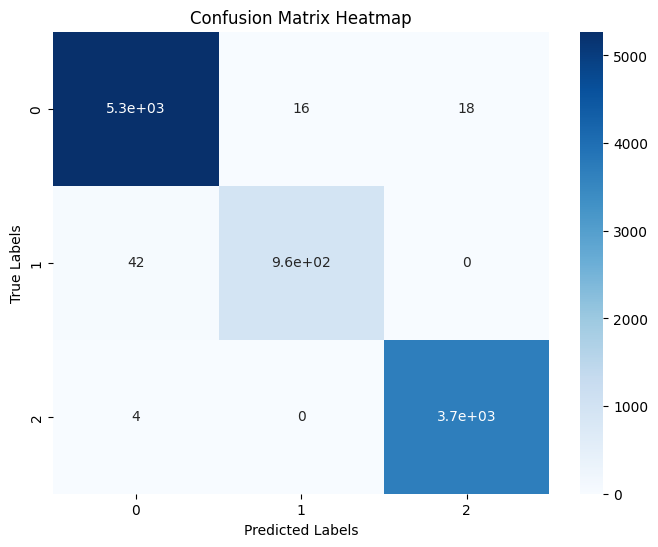

In [13]:
conf_matrix=confusion_matrix(Y_test,Y_test_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,annot=True,cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [14]:
### Recall

Macro_average_recall=recall_score(Y_test,Y_test_pred,average='macro')
Per_class_recall=recall_score(Y_test,Y_test_pred,average=None)

Macro_average_recall   ## Macro Recall and accuracy both are high. So class imbalance is not a problem

0.9835854099225093

In [15]:
Per_class_recall    ## Class imbalance is not an issue as per recall since per class recall for all 3 classes is very high.

array([0.99358974, 0.9582505 , 0.99891599])

In [16]:
## Precision

Macro_average_precision=precision_score(Y_test,Y_test_pred,average='macro')
Per_class_precision=precision_score(Y_test,Y_test_pred,average=None)

Macro_average_precision   ## Macro Average Precision is also very high

0.9900535785026818

In [17]:
Per_class_precision  ## Even per class precision is also very high

array([0.99134688, 0.98367347, 0.99514039])

In [18]:
## F1 score

Macro_average_f1_score=f1_score(Y_test,Y_test_pred,average='macro')
Per_class_f1_score=f1_score(Y_test,Y_test_pred,average=None)

Macro_average_f1_score   ## Macro Average Precision is also very high

0.986762408949907

In [19]:
Per_class_f1_score

array([0.99246704, 0.97079557, 0.99702461])

In [20]:
## Sensitivity and Specificity

mcm = multilabel_confusion_matrix(Y_test,Y_test_pred)

tn = mcm[:, 0, 0]
fp = mcm[:, 0, 1]
fn = mcm[:, 1, 0]
tp = mcm[:, 1, 1]

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

sensitivity

array([0.99358974, 0.9582505 , 0.99891599])

In [21]:
specificity

array([0.99020443, 0.99822104, 0.99714739])

In [22]:
Metrics={'Training Accuracy':Accuracy_train,'Validation Accuracy (Post Optuna Tuning)':validation_accuracy,'Test Accuracy':Accuracy_test,'Macro Average Recall':Macro_average_recall,
         'Per Class Recall':Per_class_recall,'Macro Average Precision':Macro_average_precision,'Per Class Precision':Per_class_precision,'Macro Average F1 Score':Macro_average_f1_score,
         'Per Class F1 Score':Per_class_f1_score,'Sensitivity':sensitivity,'Specificity':specificity}

Metrics=pd.Series(Metrics)

In [23]:
Metrics

Training Accuracy                                                                    0.997138
Validation Accuracy (Post Optuna Tuning)                                               0.9923
Test Accuracy                                                                           0.992
Macro Average Recall                                                                 0.983585
Per Class Recall                            [0.9935897435897436, 0.9582504970178927, 0.998...
Macro Average Precision                                                              0.990054
Per Class Precision                         [0.991346877351392, 0.9836734693877551, 0.9951...
Macro Average F1 Score                                                               0.986762
Per Class F1 Score                          [0.992467043314501, 0.9707955689828801, 0.9970...
Sensitivity                                 [0.9935897435897436, 0.9582504970178927, 0.998...
Specificity                                 [0.9902044293015

In [24]:
Metrics.to_csv(r'D:\ML Project\Model_Metrics\XGBoost.csv',header=False)